# Phân tích & Trực quan hóa Voxel 3D theo Vùng Chức Năng (NSD Subject 01)

Notebook này thực hiện:
1. Load mapping từ không gian 1D (vector) sang tọa độ 3D (x, y, z).
2. Load các ROI masks (V1-V4, Face, Place, Body, Word).
3. Tạo 3 visualizations:
   - Plot 1: Tất cả ~15k voxels (màu đơn)
   - Plot 2: Tất cả ~15k voxels được tô màu theo ROI
   - Plot 3: 518 sub-ROI centroids được tô màu theo ROI

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import nibabel as nib
import os
from sklearn.cluster import KMeans
from scipy.spatial import cKDTree
from scipy.spatial.distance import pdist, squareform
import pandas as pd

# --- Cấu hình đường dẫn ---
mapping_path = '/home/sowwn/Workspace/ws/2026/I2fMRI/data/fmri_3d_compact_mapping_subj01.npz'
roi_dir = '/mnt/HDD/dataset/NSD_raw/nsddata/ppdata/subj01/func1pt8mm/roi/'

# 1. Load Mapping 3D
print("Loading 3D mapping...")
if not os.path.exists(mapping_path):
    raise FileNotFoundError(f"Mapping file not found: {mapping_path}")

mapping = np.load(mapping_path)
mask = mapping['original_mask']  # Mask 3D gốc (boolean)
coords = mapping['coords_compact'] # Tọa độ (N, 3)
n_voxels = len(coords)
print(f"Total voxels loaded: {n_voxels}")
print(f"Coordinate shape: {coords.shape}")

Loading 3D mapping...
Total voxels loaded: 15724
Coordinate shape: (15724, 3)


In [2]:
# 2. Load ROI Labels (Masked to 1D)
def load_roi_1d(fname):
    path = os.path.join(roi_dir, fname)
    if not os.path.exists(path):
        print(f"Warning: {fname} not found, skipping.")
        return np.zeros(n_voxels)
    vol = nib.load(path).get_fdata()
    return vol[mask > 0] # Flatten theo mask đã lưu trong mapping

print("Loading ROIs...")
prf = load_roi_1d('prf-visualrois.nii.gz')
faces = load_roi_1d('floc-faces.nii.gz')
places = load_roi_1d('floc-places.nii.gz')
bodies = load_roi_1d('floc-bodies.nii.gz')
words = load_roi_1d('floc-words.nii.gz')

# 3. Tạo ROI masks và labels
roi_masks = {}
roi_masks['V1'] = (prf == 1) | (prf == 2)
roi_masks['V2'] = (prf == 3) | (prf == 4)
roi_masks['V3'] = (prf == 5) | (prf == 6)
roi_masks['hV4'] = (prf == 7)
roi_masks['Face'] = (faces > 0)
roi_masks['Place'] = (places > 0)
roi_masks['Body'] = (bodies > 0)
roi_masks['Word'] = (words > 0)

# Tạo array màu sắc cho tất cả voxels
colors = np.full((n_voxels, 3), 0.7)  # Default grey
roi_labels = np.array(['Other'] * n_voxels, dtype='object')

# Định nghĩa màu sắc cho từng ROI
roi_colors = {
    'V1': [1, 0, 0],       # Red
    'V2': [0, 1, 0],       # Green  
    'V3': [0, 0, 1],       # Blue
    'hV4': [1, 1, 0],      # Yellow
    'Face': [1, 0, 1],     # Magenta
    'Place': [0, 1, 1],    # Cyan
    'Body': [0.5, 0, 0.5], # Purple
    'Word': [1, 0.5, 0],   # Orange
    'Other': [0.7, 0.7, 0.7] # Grey
}

# Gán màu và label cho từng ROI (thứ tự ưu tiên)
for roi_name, mask_roi in roi_masks.items():
    colors[mask_roi] = roi_colors[roi_name]
    roi_labels[mask_roi] = roi_name

# In thống kê ROI
print("\nROI Statistics:")
for roi_name, mask_roi in roi_masks.items():
    n_roi = np.sum(mask_roi)
    print(f"{roi_name:>8}: {n_roi:>6} voxels ({n_roi/n_voxels*100:.1f}%)")

other_voxels = n_voxels - sum(np.sum(mask) for mask in roi_masks.values())
print(f"{'Other':>8}: {other_voxels:>6} voxels ({other_voxels/n_voxels*100:.1f}%)")

Loading ROIs...

ROI Statistics:
      V1:   1350 voxels (8.6%)
      V2:   1433 voxels (9.1%)
      V3:   1187 voxels (7.5%)
     hV4:    687 voxels (4.4%)
    Face:   1042 voxels (6.6%)
   Place:   2252 voxels (14.3%)
    Body:   2934 voxels (18.7%)
    Word:   1736 voxels (11.0%)
   Other:   3103 voxels (19.7%)


## Plot 1: Tất cả ~15k Voxels (Màu đơn)
Hiển thị tất cả voxels trong không gian 3D với màu đơn để xem cấu trúc tổng thể.

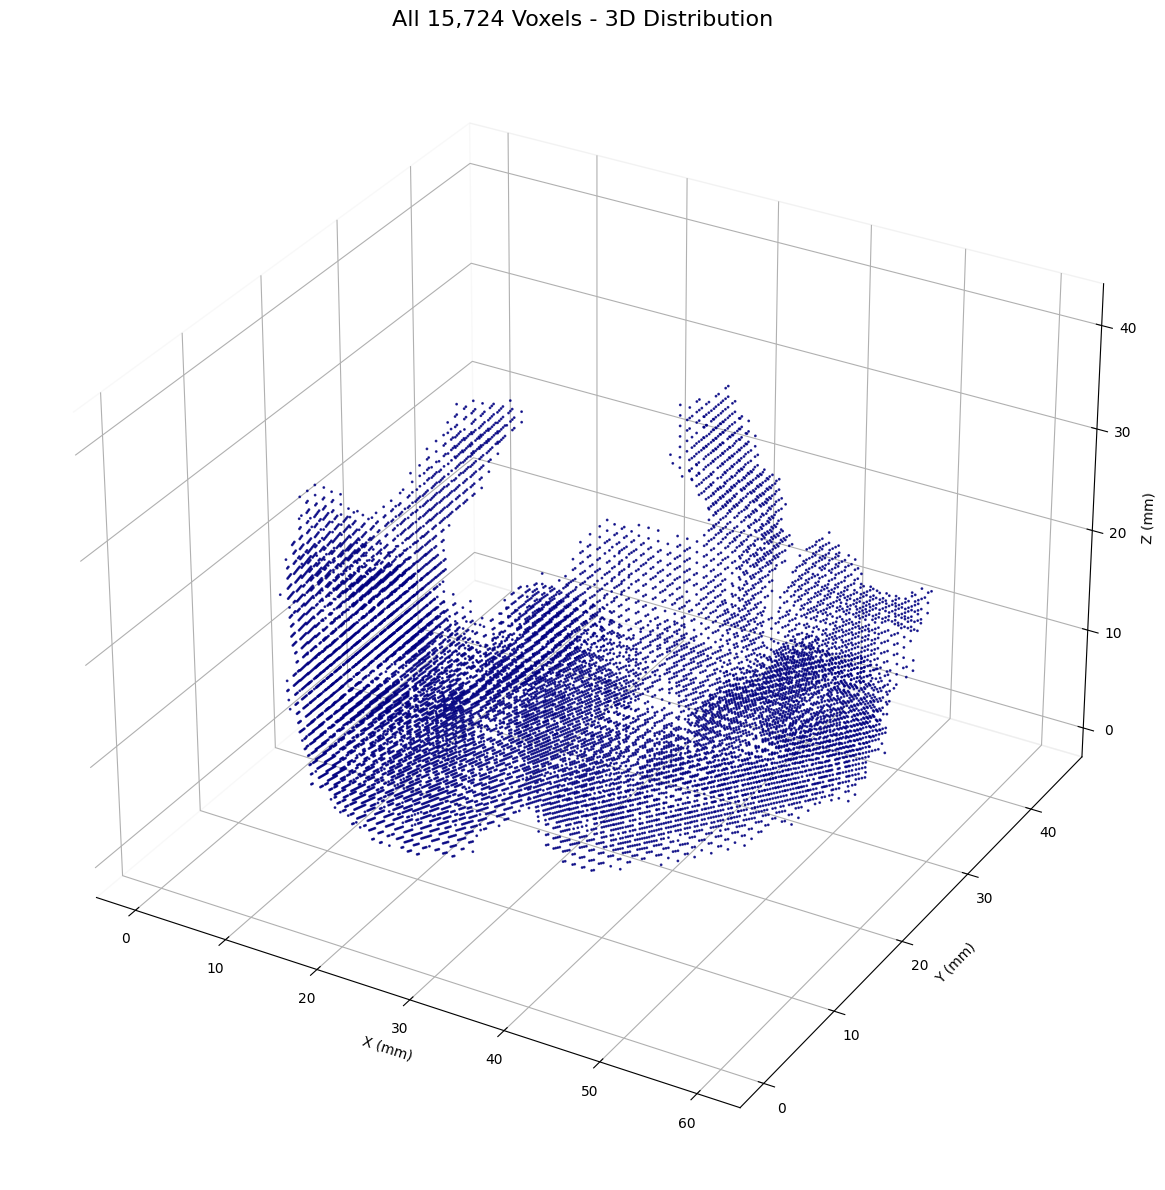

In [3]:
# PLOT 1: Tất cả voxels với màu đơn đậm
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot đơn giản với màu đậm
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], 
           c='navy', s=1.0, alpha=0.8)

ax.set_title(f'All {n_voxels:,} Voxels - 3D Distribution', fontsize=16)
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')

# Styling
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Creating ROI visualization with bold colors...


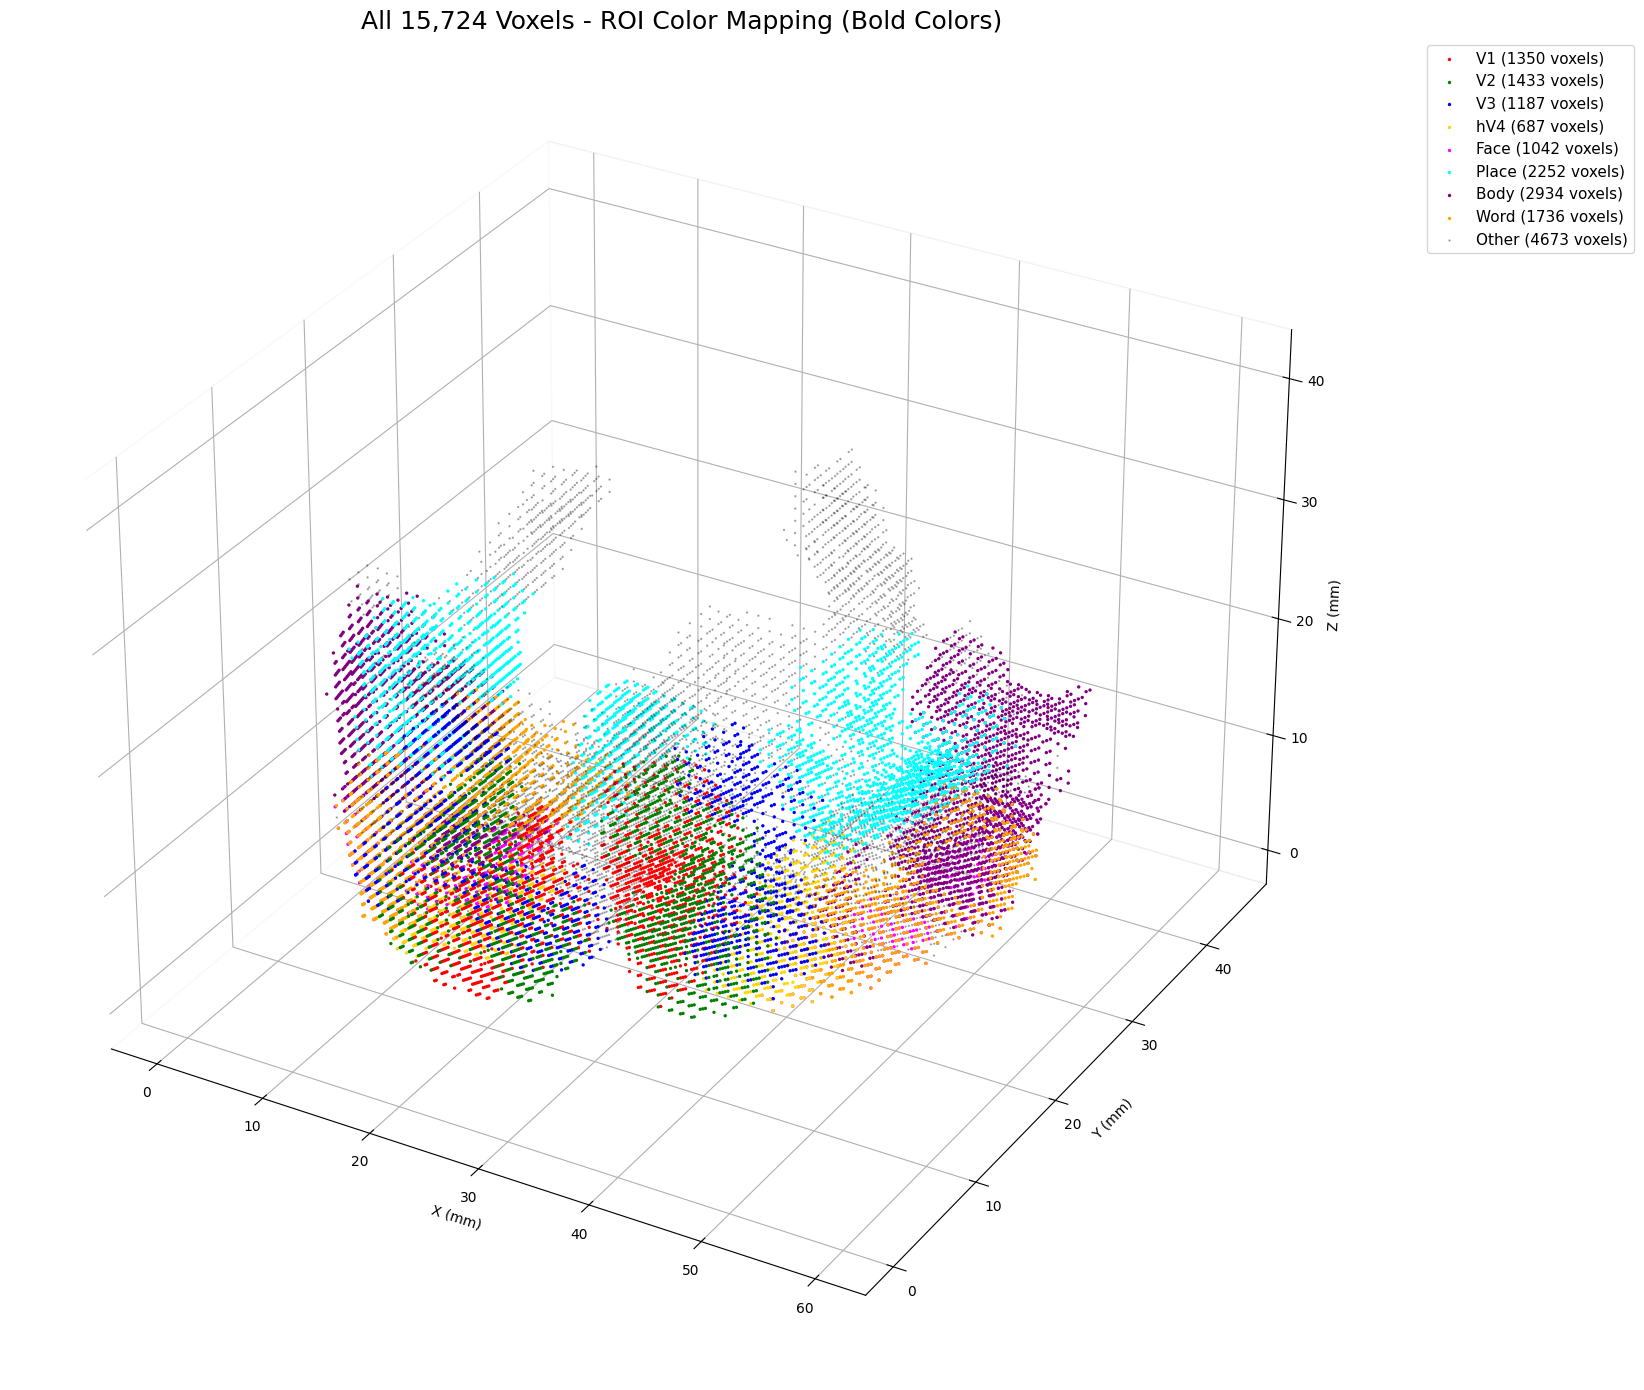

In [4]:
# PLOT 2: Tất cả voxels với màu đậm theo ROI
fig = plt.figure(figsize=(16, 14))
ax = fig.add_subplot(111, projection='3d')

print("Creating ROI visualization with bold colors...")

# Màu đậm hơn cho ROIs
bold_roi_colors = {
    'V1': 'red',           # Đậm
    'V2': 'green',         # Đậm  
    'V3': 'blue',          # Đậm
    'hV4': 'gold',         # Đậm
    'Face': 'magenta',     # Đậm
    'Place': 'cyan',       # Đậm
    'Body': 'purple',      # Đậm
    'Word': 'orange'       # Đậm
}

# Plot từng ROI với màu đậm
for roi_name, mask_roi in roi_masks.items():
    if np.sum(mask_roi) > 0:
        roi_coords = coords[mask_roi]
        n_roi = len(roi_coords)
        
        ax.scatter(roi_coords[:, 0], roi_coords[:, 1], roi_coords[:, 2], 
                  c=bold_roi_colors[roi_name], s=2.0, alpha=1, 
                  label=f'{roi_name} ({n_roi} voxels)')

# Plot Other voxels với màu nhạt
other_mask = np.ones(n_voxels, dtype=bool)
for mask_roi in roi_masks.values():
    other_mask = other_mask & (~mask_roi)

if np.sum(other_mask) > 0:
    other_coords = coords[other_mask]
    ax.scatter(other_coords[:, 0], other_coords[:, 1], other_coords[:, 2], 
              c='black', s=0.5, alpha=0.3, 
              label=f'Other ({np.sum(other_mask)} voxels)')

ax.set_title(f'All {n_voxels:,} Voxels - ROI Color Mapping (Bold Colors)', fontsize=18)
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [5]:
# Tạo Sub-ROI clusters đơn giản
VOXELS_PER_CLUSTER = 30

sub_roi_labels = np.zeros(n_voxels, dtype=int)
sub_roi_centroids = []
sub_roi_colors = []
sub_roi_names = []
current_cluster_id = 0

# Xử lý từng ROI
all_regions = list(roi_masks.keys())
other_mask = np.ones(n_voxels, dtype=bool)
for mask_roi in roi_masks.values():
    other_mask = other_mask & (~mask_roi)
all_regions.append('Other')

print("Creating Sub-ROI clusters...")
print("{:<10} {:<10} {:<10}".format("Region", "Voxels", "Clusters"))
print("-"*35)

for roi_name in all_regions:
    if roi_name == 'Other':
        idx_mask = other_mask
    else:
        idx_mask = roi_masks[roi_name]
    
    n_region_voxels = np.sum(idx_mask)
    if n_region_voxels == 0: 
        continue
        
    k = max(1, int(n_region_voxels / VOXELS_PER_CLUSTER))
    region_coords = coords[idx_mask]
    
    if k == 1:
        centroid = np.mean(region_coords, axis=0)
        local_labels = np.zeros(n_region_voxels, dtype=int)
    else:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        local_labels = kmeans.fit_predict(region_coords)
        centroid = kmeans.cluster_centers_
    
    global_labels = local_labels + current_cluster_id
    sub_roi_labels[idx_mask] = global_labels
    
    # Lưu centroids
    if k == 1:
        sub_roi_centroids.append(centroid)
        sub_roi_colors.append(bold_roi_colors.get(roi_name, 'gray'))
        sub_roi_names.append(roi_name)
    else:
        for i in range(k):
            sub_roi_centroids.append(centroid[i])
            sub_roi_colors.append(bold_roi_colors.get(roi_name, 'gray'))
            sub_roi_names.append(roi_name)
    
    print("{:<10} {:<10} {:<10}".format(roi_name, n_region_voxels, k))
    current_cluster_id += k

sub_roi_centroids = np.array(sub_roi_centroids)
n_clusters = len(sub_roi_centroids)

print("-"*35)
print(f"Total Sub-ROI clusters: {n_clusters}")

Creating Sub-ROI clusters...
Region     Voxels     Clusters  
-----------------------------------
V1         1350       45        
V2         1433       47        
V3         1187       39        
hV4        687        22        
Face       1042       34        
Place      2252       75        
Body       2934       97        
Word       1736       57        
Other      4673       155       
-----------------------------------
Total Sub-ROI clusters: 571


Creating sub-ROI visualization with bold colors...


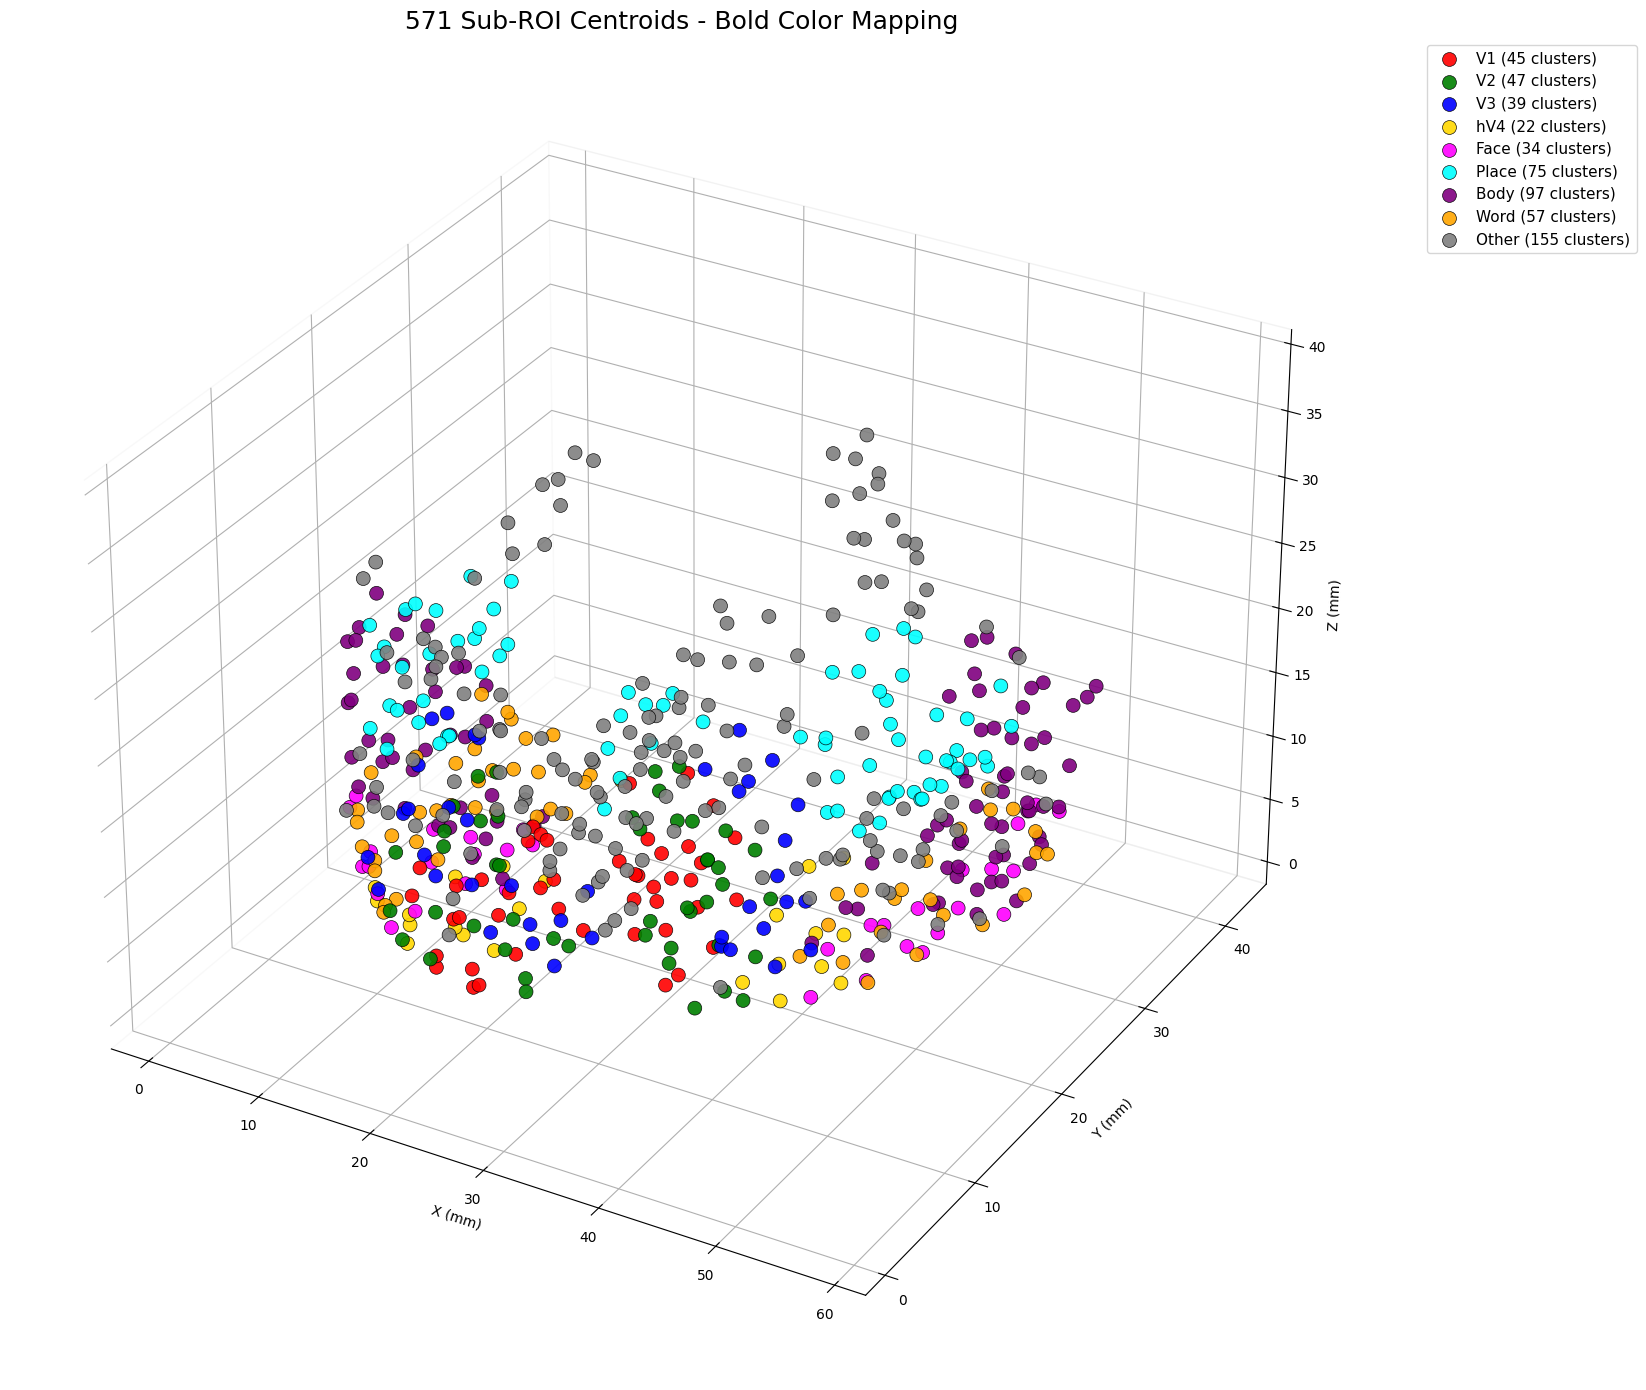

In [6]:
# PLOT 3: Sub-ROI centroids với màu đậm (Fixed rotation)
fig = plt.figure(figsize=(16, 14))
ax = fig.add_subplot(111, projection='3d')

print("Creating sub-ROI visualization with bold colors...")

# Group centroids by ROI
roi_centroid_groups = {}
for roi_name in list(bold_roi_colors.keys()) + ['Other']:
    roi_centroid_groups[roi_name] = {
        'coords': [], 
        'color': bold_roi_colors.get(roi_name, 'gray')
    }

for i, (centroid, color, name) in enumerate(zip(sub_roi_centroids, sub_roi_colors, sub_roi_names)):
    roi_centroid_groups[name]['coords'].append(centroid)

# Plot từng nhóm với màu đậm
for roi_name, group in roi_centroid_groups.items():
    if len(group['coords']) > 0:
        coords_array = np.array(group['coords'])
        n_centroids = len(coords_array)
        
        # Size lớn hơn cho centroids
        cluster_size = 100
        
        ax.scatter(coords_array[:, 0], coords_array[:, 1], coords_array[:, 2], 
                  c=group['color'], s=cluster_size, alpha=0.9, 
                  label=f'{roi_name} ({n_centroids} clusters)',
                  edgecolors='black', linewidths=0.5)

ax.set_title(f'{n_clusters} Sub-ROI Centroids - Bold Color Mapping', fontsize=18)
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False  
ax.zaxis.pane.fill = False
ax.grid(True, alpha=0.2)

# Fix rotation - same as other plots
# ax.view_init(elev=20, azim=45)  # Remove this line for default view

plt.tight_layout()
plt.show()

## 1D Visualizations - Load Actual fMRI Data (Added)
Tải và hiển thị giá trị fMRI (betas) cho một ảnh mẫu, chuẩn bị dữ liệu cho 3 plot 1D.

In [8]:
# Load betas - tìm file beta hợp lệ
import h5py
from scipy.ndimage import gaussian_filter1d
import matplotlib.patches as patches

# Thử các đường dẫn có thể
possible_beta_paths = [
    '/mnt/HDD/dataset/NSD/subj01/betas_all_subj01_fp32_renorm.hdf5',
    '/home/sowwn/Workspace/ws/2026/I2fMRI/dataset/nsd/subj01/betas_all_subj01_fp32_renorm.hdf5',
    '/mnt/HDD/dataset/NSD_raw/nsddata_betas/ppdata/subj01/func1pt8mm/betas_fithrf_GLMdenoise_RR/betas_session01.hdf5',
]

beta_path = None
for path in possible_beta_paths:
    if os.path.exists(path):
        beta_path = path
        break

if beta_path is None:
    raise FileNotFoundError(f"Could not find beta file. Tried paths:\n" + "\n".join(possible_beta_paths))

sample_image_index = 100  # thay đổi nếu cần

print("Loading betas from:", beta_path)
with h5py.File(beta_path, 'r') as f:
    # Liệt kê các dataset có sẵn
    print("Available datasets:", list(f.keys()))
    
    # Thử load dataset (tên có thể là 'betas', 'voxel', hoặc key đầu tiên)
    if 'betas' in f:
        betas_all = f['betas']
    elif 'voxel' in f:
        betas_all = f['voxel']
    else:
        betas_all = list(f.values())[0]
    
    print(f"Beta dataset shape: {betas_all.shape}")
    
    # Kiểm tra số voxel khớp
    if betas_all.shape[-1] != n_voxels:
        print(f"Warning: Voxel count mismatch! Mapping has {n_voxels}, Betas has {betas_all.shape[-1]}")
        print("Will try to align or truncate...")
        # Nếu shape là (n_images, n_voxels)
        if len(betas_all.shape) == 2 and betas_all.shape[0] > betas_all.shape[1]:
            voxel_data_1d = betas_all[sample_image_index, :min(n_voxels, betas_all.shape[1])]
        else:
            voxel_data_1d = betas_all[sample_image_index, :n_voxels]
    else:
        if len(betas_all.shape) == 2:
            voxel_data_1d = betas_all[sample_image_index, :]
        else:
            # Nếu có thêm dimensions
            voxel_data_1d = betas_all[sample_image_index].flatten()[:n_voxels]

print(f"Loaded voxel vector shape: {voxel_data_1d.shape}")

Loading betas from: /home/sowwn/Workspace/ws/2026/I2fMRI/dataset/nsd/subj01/betas_all_subj01_fp32_renorm.hdf5
Available datasets: ['betas']
Beta dataset shape: (30000, 15724)
Loaded voxel vector shape: (15724,)


In [9]:
# Prepare DataFrame and pooled values
# roi_labels, sub_roi_labels, bold_roi_colors exist from earlier cells
categories = list(bold_roi_colors.keys()) + ['Other']
roi_cat = pd.CategoricalDtype(categories=categories, ordered=True)

df = pd.DataFrame({
    'voxel': voxel_data_1d,
    'roi': roi_labels,
    'sub_roi': sub_roi_labels
})
df['roi'] = df['roi'].astype(roi_cat)

# Sort by roi then sub_roi
df_sorted = df.sort_values(by=['roi', 'sub_roi']).reset_index(drop=True)
sorted_voxels = df_sorted['voxel'].values
smoothed_voxels = gaussian_filter1d(sorted_voxels.astype(float), sigma=20)

# pooled by sub_roi (mean), keep roi label for each pooled item
pooled_df = df_sorted.groupby('sub_roi', sort=False).agg(
    pooled_voxel=('voxel', 'mean'),
    roi=('roi', 'first')
).reset_index().sort_values(by='roi')
pooled_voxels = pooled_df['pooled_voxel'].values
pooled_rois = pooled_df['roi'].values

print("Prepared:")
print(" - sorted_voxels:", sorted_voxels.shape)
print(" - smoothed_voxels:", smoothed_voxels.shape)
print(" - pooled_voxels:", pooled_voxels.shape)

Prepared:
 - sorted_voxels: (15724,)
 - smoothed_voxels: (15724,)
 - pooled_voxels: (561,)


### Plot 1: 15k Voxels (sắp xếp theo ROI) + Smoothed

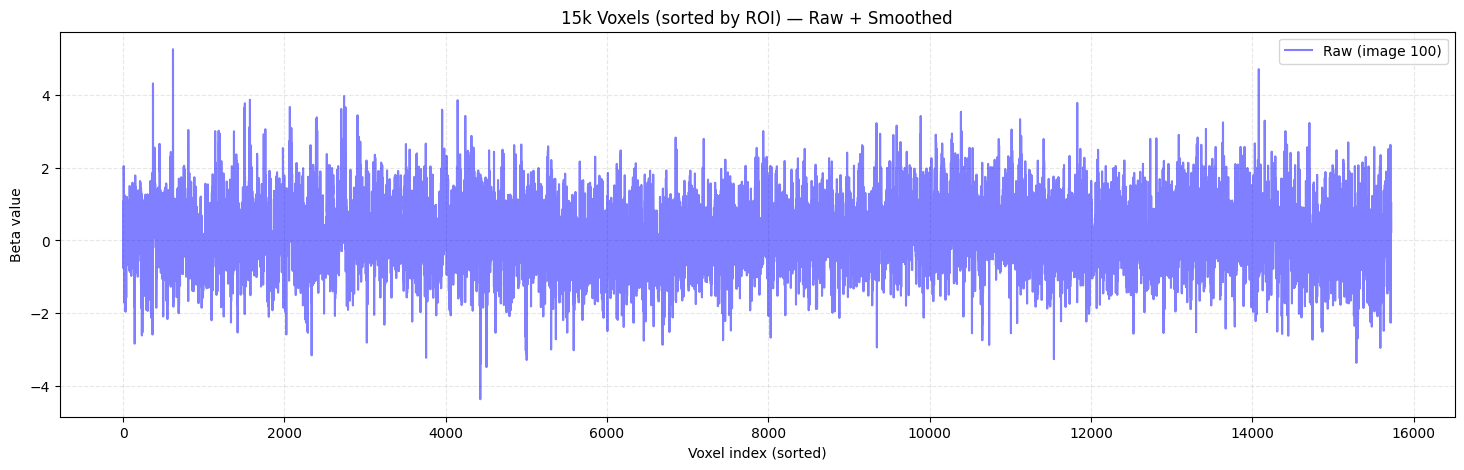

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))
plt.plot(sorted_voxels, color='blue', alpha=0.5, label=f'Raw (image {sample_image_index})')
# plt.plot(smoothed_voxels, color='blue', linewidth=2.0, label='Smoothed (sigma=20)')
plt.title('15k Voxels (sorted by ROI) — Raw + Smoothed')
plt.xlabel('Voxel index (sorted)')
plt.ylabel('Beta value')
plt.legend()
plt.grid(alpha=0.3, linestyle='--')
plt.show()

In [11]:
### Plot 2: 15k Voxels với nền được tô màu theo ROI

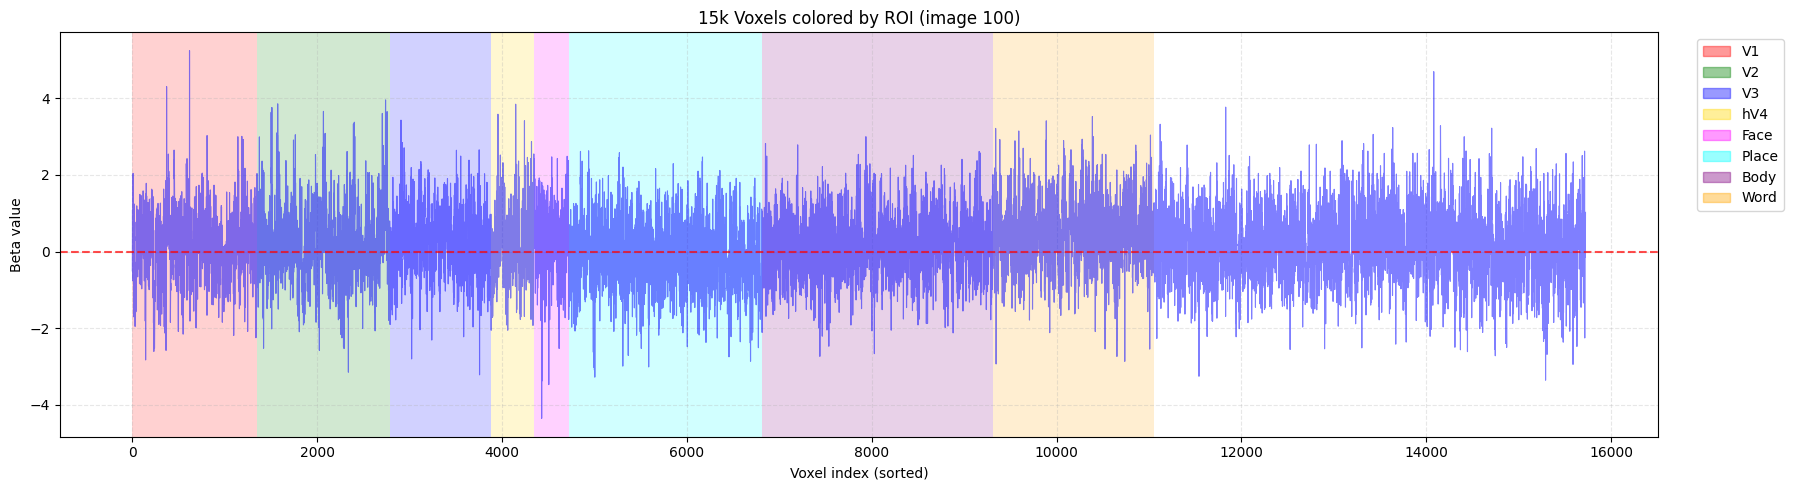

In [20]:
fig, ax = plt.subplots(figsize=(18,5))
ax.plot(sorted_voxels, color='blue', linewidth=0.8, alpha=0.5)

# Thêm đường baseline y=0
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='y=0 baseline')

# roi region counts in the sorted order
roi_counts = df_sorted['roi'].value_counts().reindex(categories, fill_value=0)
roi_cum = roi_counts.cumsum()
roi_starts = roi_cum.shift(1, fill_value=0)

ymin, ymax = ax.get_ylim()
legend_patches = []
for roi_name in categories:
    count = roi_counts[roi_name]
    if count == 0 or roi_name == 'Other':
        continue
    start = int(roi_starts[roi_name])
    color = bold_roi_colors.get(roi_name, 'gray')
    rect = patches.Rectangle((start, ymin), count, ymax - ymin, facecolor=color, alpha=0.18, edgecolor=None)
    ax.add_patch(rect)
    legend_patches.append(patches.Patch(color=color, label=roi_name, alpha=0.4))

ax.set_title(f'15k Voxels colored by ROI (image {sample_image_index})')
ax.set_xlabel('Voxel index (sorted)')
ax.set_ylabel('Beta value')
ax.legend(handles=legend_patches, bbox_to_anchor=(1.02,1), loc='upper left')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
### Plot 3: ~500 Pooled Voxels (sub-ROIs) với nền được tô màu theo ROI

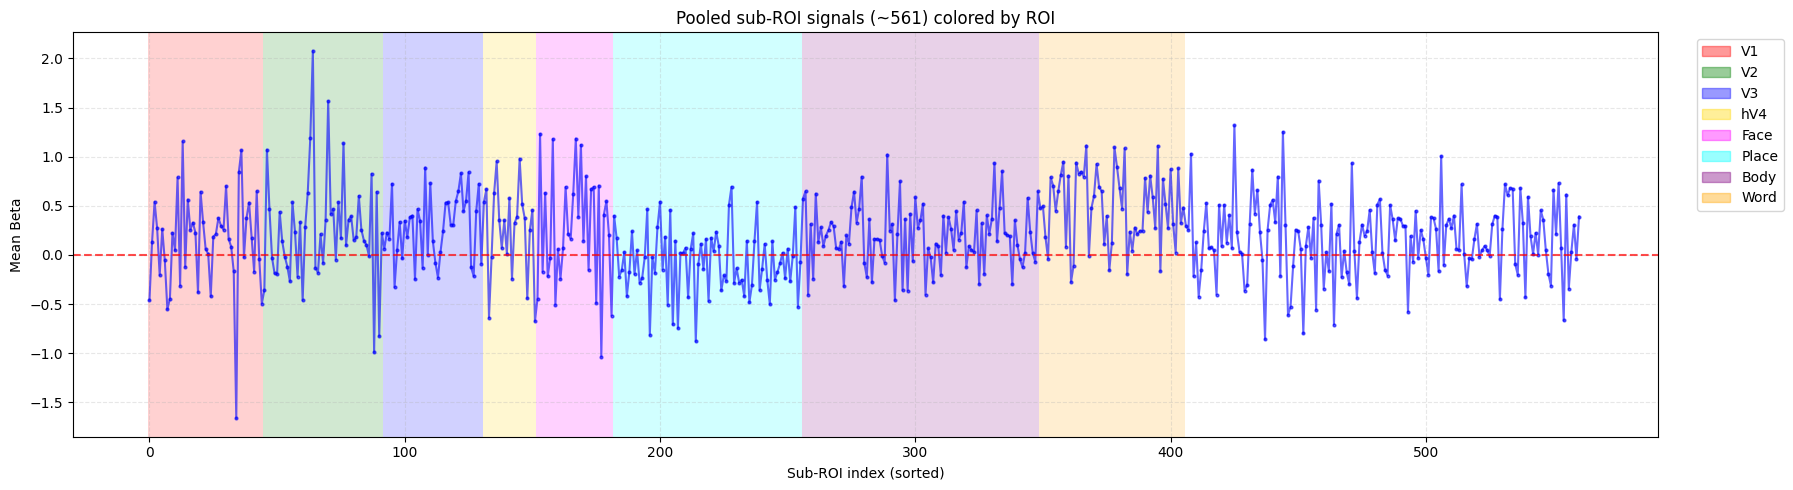

In [27]:
fig, ax = plt.subplots(figsize=(18,5))

# Sử dụng x_positions bình thường, không thêm padding vào giá trị
x_positions = np.arange(len(pooled_voxels))

# Plot
ax.plot(x_positions, pooled_voxels, color='blue', alpha=0.6, linewidth=1.5, marker='o', markersize=2)

# Thêm đường baseline y=0
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='y=0 baseline')

# pooled roi counts (ordered)
pooled_counts = pooled_df['roi'].value_counts().reindex(categories, fill_value=0)
pooled_cum = pooled_counts.cumsum()
pooled_starts = pooled_cum.shift(1, fill_value=0)

ymin, ymax = ax.get_ylim()
legend_patches = []

# Vẽ background cho từng ROI
for roi_name in categories:
    count = pooled_counts[roi_name]
    if count == 0 or roi_name == 'Other':
        continue
    
    start = int(pooled_starts[roi_name])
    color = bold_roi_colors.get(roi_name, 'gray')
    rect = patches.Rectangle((start - 0.5, ymin), count, ymax - ymin, 
                             facecolor=color, alpha=0.18, edgecolor=None)
    ax.add_patch(rect)
    legend_patches.append(patches.Patch(color=color, label=roi_name, alpha=0.4))

ax.set_title(f'Pooled sub-ROI signals (~{len(pooled_voxels)}) colored by ROI')
ax.set_xlabel('Sub-ROI index (sorted)')
ax.set_ylabel('Mean Beta')
ax.legend(handles=legend_patches, bbox_to_anchor=(1.02,1), loc='upper left')
ax.grid(alpha=0.3, linestyle='--')
# Thêm padding trực quan bằng cách mở rộng xlim, nhưng vẫn giữ tick labels từ 0
ax.set_xlim(-30, len(pooled_voxels) + 30)
plt.tight_layout()
plt.show()